In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload your Excel file (the wide WDI format you showed)
uploaded = files.upload()
fname = list(uploaded.keys())[0]

# Read and reshape to tidy format
df = pd.read_excel(fname, header=0)
df.columns = df.columns.astype(str).str.strip()
year_cols = [c for c in df.columns if c.isdigit()]

long_df = df.melt(
    id_vars=['Country Name','Country Code','Indicator Name','Indicator Code'],
    value_vars=year_cols,
    var_name='Year', value_name='Value'
)

tidy_df = long_df.pivot_table(
    index=['Country Name','Country Code','Year'],
    columns='Indicator Name', values='Value'
).reset_index()

tidy_df = tidy_df.rename(columns={
    'Individuals using the Internet (% of population)': 'internet_pct',
    'GDP growth (annual %)': 'gdp_growth',
    'GNI per capita, Atlas method (current US$)': 'gni_pc',
    'Population, total': 'population'
})

tidy_df['Year'] = pd.to_numeric(tidy_df['Year'], errors='coerce')
for col in ['internet_pct','gdp_growth','gni_pc','population']:
    tidy_df[col] = pd.to_numeric(tidy_df[col], errors='coerce')

# Kenya only, sorted by year
tidy_df = tidy_df[tidy_df['Country Code'] == 'KEN'].sort_values('Year')
print(tidy_df.head())


Saving 1.xlsx to 1 (7).xlsx
Indicator Name Country Name Country Code  Year  gdp_growth  gni_pc  \
0                     Kenya          KEN  1960         NaN     NaN   
1                     Kenya          KEN  1961   -7.774635     NaN   
2                     Kenya          KEN  1962    9.457359   100.0   
3                     Kenya          KEN  1963    8.778340   110.0   
4                     Kenya          KEN  1964    4.964467   110.0   

Indicator Name  internet_pct  population  
0                        NaN   7695307.0  
1                        NaN   7987770.0  
2                        NaN   8299308.0  
3                        NaN   8627971.0  
4                        NaN   8973535.0  


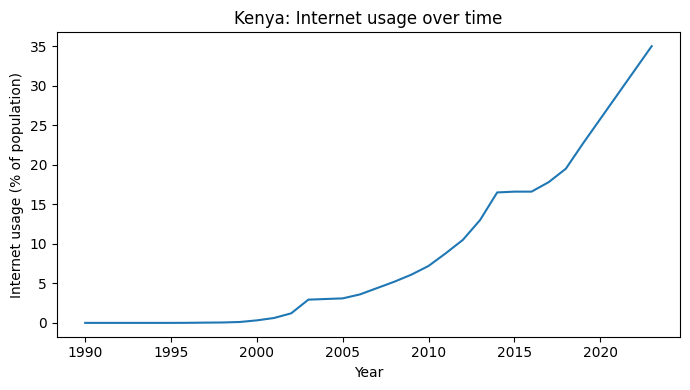

In [ ]:
# Line chart: Internet usage over time
data = tidy_df[['Year', 'internet_pct']].dropna()

plt.figure(figsize=(7,4))
plt.plot(data['Year'], data['internet_pct'])
plt.xlabel('Year')
plt.ylabel('Internet usage (% of population)')
plt.title('Kenya: Internet usage over time')
plt.tight_layout()
plt.show()

# Optional: save
plt.figure(figsize=(7,4))
plt.plot(data['Year'], data['internet_pct'])
plt.xlabel('Year'); plt.ylabel('Internet usage (% of population)')
plt.title('Kenya: Internet usage over time')
plt.tight_layout()
plt.savefig('chart01_internet_trend.png', dpi=200)
plt.close()


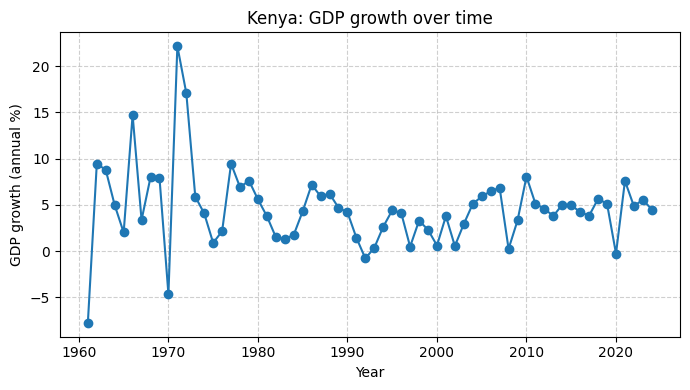

In [ ]:
# Line chart: GDP growth over time
data = tidy_df[['Year', 'gdp_growth']].dropna()

plt.figure(figsize=(7,4))
plt.plot(data['Year'], data['gdp_growth'], marker='o')
plt.xlabel('Year')
plt.ylabel('GDP growth (annual %)')
plt.title('Kenya: GDP growth over time')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Optional: save to file
plt.figure(figsize=(7,4))
plt.plot(data['Year'], data['gdp_growth'], marker='o')
plt.xlabel('Year')
plt.ylabel('GDP growth (annual %)')
plt.title('Kenya: GDP growth over time')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('chart02_gdp_growth_trend.png', dpi=200)
plt.close()


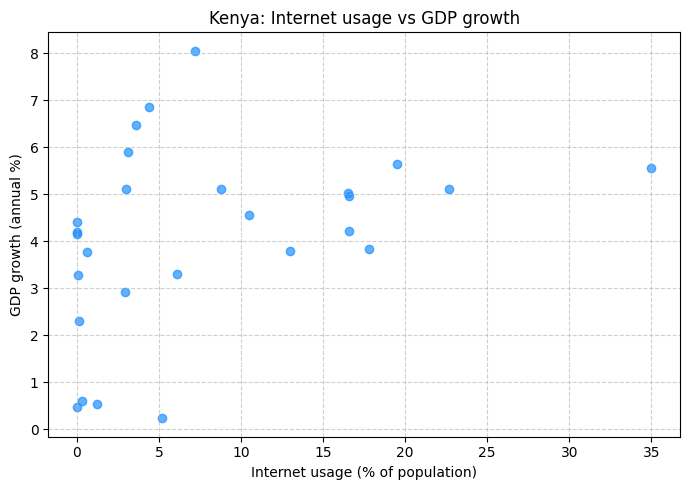

In [ ]:
# Scatter plot: Internet usage vs GDP growth
data = tidy_df[['internet_pct', 'gdp_growth']].dropna()

plt.figure(figsize=(7,5))
plt.scatter(data['internet_pct'], data['gdp_growth'], color='dodgerblue', alpha=0.7)
plt.xlabel('Internet usage (% of population)')
plt.ylabel('GDP growth (annual %)')
plt.title('Kenya: Internet usage vs GDP growth')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Optional: save to file
plt.figure(figsize=(7,5))
plt.scatter(data['internet_pct'], data['gdp_growth'], color='dodgerblue', alpha=0.7)
plt.xlabel('Internet usage (% of population)')
plt.ylabel('GDP growth (annual %)')
plt.title('Kenya: Internet usage vs GDP growth')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('chart03_scatter_internet_vs_gdp.png', dpi=200)
plt.close()


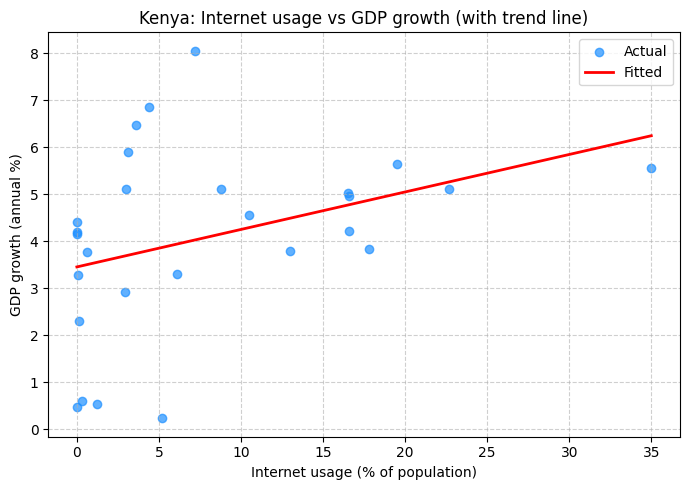

In [ ]:
import numpy as np

# Prepare data
data = tidy_df[['internet_pct', 'gdp_growth']].dropna()
x = data['internet_pct']
y = data['gdp_growth']

# Fit linear regression line
m, b = np.polyfit(x, y, 1)

# Plot scatter and regression line
plt.figure(figsize=(7,5))
plt.scatter(x, y, color='dodgerblue', alpha=0.7, label='Actual')
plt.plot(x, m*x + b, color='red', linewidth=2, label='Fitted')
plt.xlabel('Internet usage (% of population)')
plt.ylabel('GDP growth (annual %)')
plt.title('Kenya: Internet usage vs GDP growth (with trend line)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Optional: save to file
plt.figure(figsize=(7,5))
plt.scatter(x, y, color='dodgerblue', alpha=0.7, label='Actual')
plt.plot(x, m*x + b, color='red', linewidth=2, label='Fitted')
plt.xlabel('Internet usage (% of population)')
plt.ylabel('GDP growth (annual %)')
plt.title('Kenya: Internet usage vs GDP growth (with trend line)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('chart04_scatter_trend.png', dpi=200)
plt.close()


Saving 1.xlsx to 1 (8).xlsx


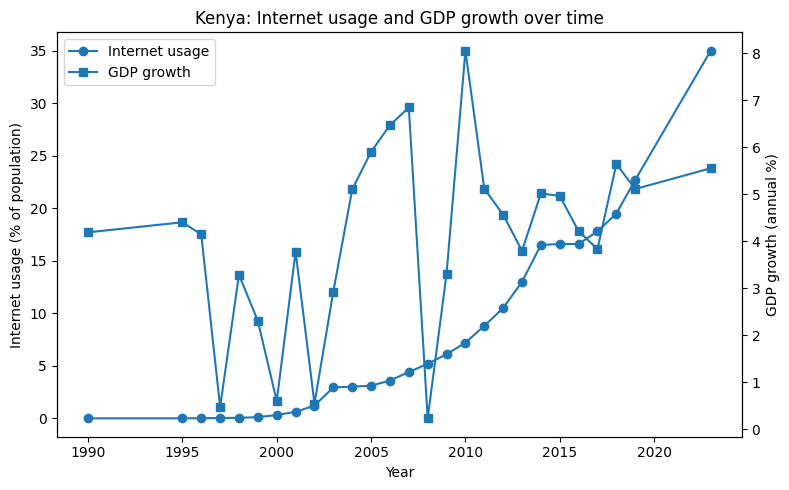

Saved to chart05_dual_axis.png


In [ ]:
# Dual-axis Time Series — Internet usage & GDP growth
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 1) Upload and read the wide WDI Excel
uploaded = files.upload()
fname = list(uploaded.keys())[0]

df = pd.read_excel(fname, header=0)
df.columns = df.columns.astype(str).str.strip()

# 2) Identify year columns (e.g., "1960", "2000", ...)
year_cols = [c for c in df.columns if c.isdigit()]

# 3) Melt to long format: one row per Year
long_df = df.melt(
    id_vars=['Country Name','Country Code','Indicator Name','Indicator Code'],
    value_vars=year_cols,
    var_name='Year', value_name='Value'
)

# 4) Pivot so each indicator becomes a column
tidy_df = long_df.pivot_table(
    index=['Country Name','Country Code','Year'],
    columns='Indicator Name', values='Value'
).reset_index()

# 5) Rename indicators for easier typing
tidy_df = tidy_df.rename(columns={
    'Individuals using the Internet (% of population)': 'internet_pct',
    'GDP growth (annual %)': 'gdp_growth',
    'GNI per capita, Atlas method (current US$)': 'gni_pc',
    'Population, total': 'population'
})

# 6) Ensure numeric types and keep Kenya
tidy_df['Year'] = pd.to_numeric(tidy_df['Year'], errors='coerce')
for col in ['internet_pct','gdp_growth','gni_pc','population']:
    tidy_df[col] = pd.to_numeric(tidy_df[col], errors='coerce')
tidy_df = tidy_df[tidy_df['Country Code'] == 'KEN'].sort_values('Year')

# 7) Build aligned series for the two axes
plot_df = tidy_df[['Year','internet_pct','gdp_growth']].dropna().sort_values('Year')

# 8) Plot dual-axis chart
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(plot_df['Year'], plot_df['internet_pct'], marker='o', label='Internet usage')
ax1.set_xlabel('Year')
ax1.set_ylabel('Internet usage (% of population)')
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.plot(plot_df['Year'], plot_df['gdp_growth'], marker='s', label='GDP growth')
ax2.set_ylabel('GDP growth (annual %)')
ax2.tick_params(axis='y')

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Kenya: Internet usage and GDP growth over time')
fig.tight_layout()
plt.show()

# 9) Save figure
fig.savefig('chart05_dual_axis.png', dpi=200)
print("Saved to chart05_dual_axis.png")


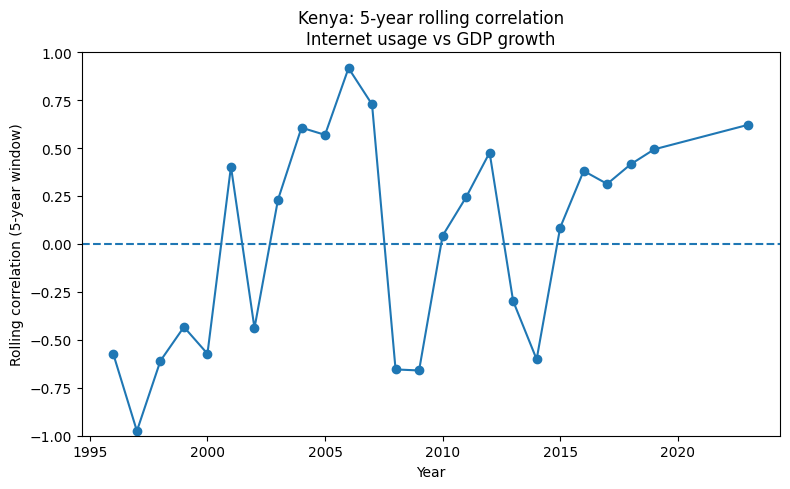

In [ ]:
# Rolling 5-year correlation between Internet usage and GDP growth

rc_df = tidy_df[['Year','internet_pct','gdp_growth']].dropna().sort_values('Year').copy()

# 5-year rolling correlation
rc_df['roll_corr_5y'] = rc_df['internet_pct'].rolling(window=5, min_periods=3)\
                           .corr(rc_df['gdp_growth'])

plt.figure(figsize=(8,5))
plt.plot(rc_df['Year'], rc_df['roll_corr_5y'], marker='o')
plt.axhline(0, linestyle='--')
plt.ylim(-1, 1)
plt.xlabel('Year')
plt.ylabel('Rolling correlation (5-year window)')
plt.title('Kenya: 5-year rolling correlation\nInternet usage vs GDP growth')
plt.tight_layout()
plt.show()

# Save
plt.figure(figsize=(8,5))
plt.plot(rc_df['Year'], rc_df['roll_corr_5y'], marker='o')
plt.axhline(0, linestyle='--')
plt.ylim(-1, 1)
plt.xlabel('Year')
plt.ylabel('Rolling correlation (5-year window)')
plt.title('Kenya: 5-year rolling correlation\nInternet usage vs GDP growth')
plt.tight_layout()
plt.savefig('chart07_rolling_correlation_5y.png', dpi=200)
plt.close()


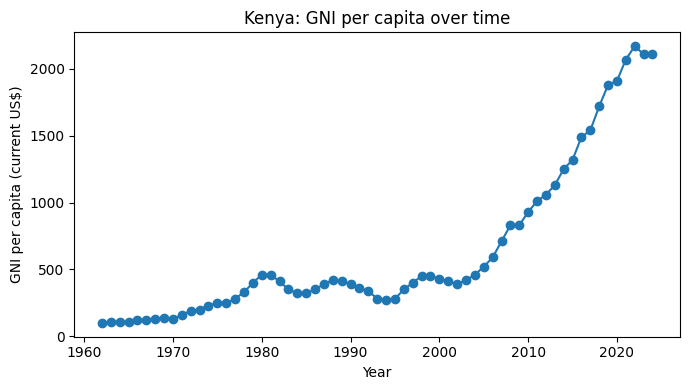

In [ ]:
# Year vs GNI per capita (line)
gni_ts = tidy_df[['Year','gni_pc']].dropna().sort_values('Year')

plt.figure(figsize=(7,4))
plt.plot(gni_ts['Year'], gni_ts['gni_pc'], marker='o')
plt.xlabel('Year')
plt.ylabel('GNI per capita (current US$)')
plt.title('Kenya: GNI per capita over time')
plt.tight_layout()
plt.show()

# save
plt.figure(figsize=(7,4))
plt.plot(gni_ts['Year'], gni_ts['gni_pc'], marker='o')
plt.xlabel('Year'); plt.ylabel('GNI per capita (current US$)')
plt.title('Kenya: GNI per capita over time')
plt.tight_layout(); plt.savefig('chart_gni_over_time.png', dpi=200); plt.close()


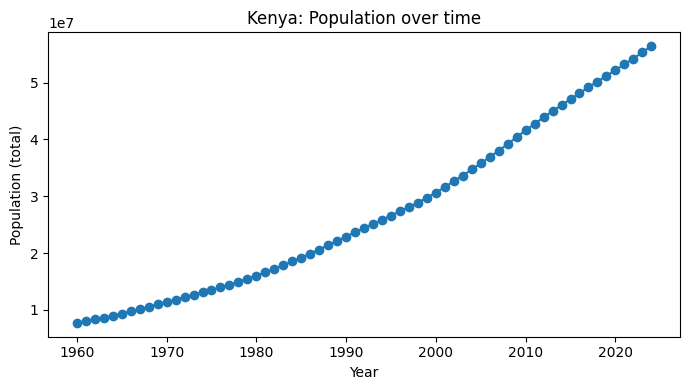

In [ ]:
# Year vs Population (line)
pop_ts = tidy_df[['Year','population']].dropna().sort_values('Year')

plt.figure(figsize=(7,4))
plt.plot(pop_ts['Year'], pop_ts['population'], marker='o')
plt.xlabel('Year')
plt.ylabel('Population (total)')
plt.title('Kenya: Population over time')
plt.tight_layout()
plt.show()

# save
plt.figure(figsize=(7,4))
plt.plot(pop_ts['Year'], pop_ts['population'], marker='o')
plt.xlabel('Year'); plt.ylabel('Population (total)')
plt.title('Kenya: Population over time')
plt.tight_layout(); plt.savefig('chart_population_over_time.png', dpi=200); plt.close()


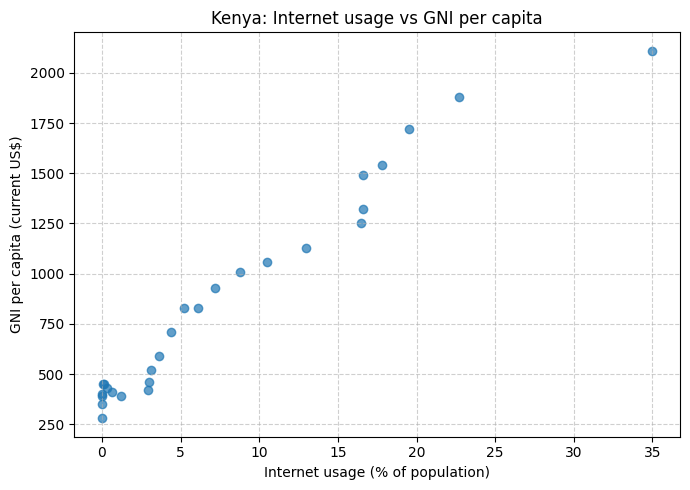

In [ ]:
# Scatter: Internet usage vs GNI per capita
ig = tidy_df[['internet_pct','gni_pc']].dropna()

plt.figure(figsize=(7,5))
plt.scatter(ig['internet_pct'], ig['gni_pc'], alpha=0.7)
plt.xlabel('Internet usage (% of population)')
plt.ylabel('GNI per capita (current US$)')
plt.title('Kenya: Internet usage vs GNI per capita')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# save
plt.figure(figsize=(7,5))
plt.scatter(ig['internet_pct'], ig['gni_pc'], alpha=0.7)
plt.xlabel('Internet usage (% of population)')
plt.ylabel('GNI per capita (current US$)')
plt.title('Kenya: Internet usage vs GNI per capita')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.savefig('chart_internet_vs_gni.png', dpi=200); plt.close()


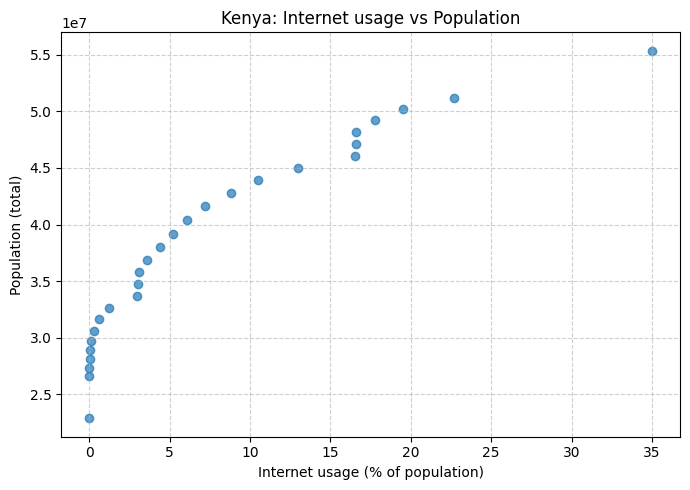

In [ ]:
# Scatter: Internet usage vs Population
ip = tidy_df[['internet_pct','population']].dropna()

plt.figure(figsize=(7,5))
plt.scatter(ip['internet_pct'], ip['population'], alpha=0.7)
plt.xlabel('Internet usage (% of population)')
plt.ylabel('Population (total)')
plt.title('Kenya: Internet usage vs Population')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# save
plt.figure(figsize=(7,5))
plt.scatter(ip['internet_pct'], ip['population'], alpha=0.7)
plt.xlabel('Internet usage (% of population)')
plt.ylabel('Population (total)')
plt.title('Kenya: Internet usage vs Population')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.savefig('chart_internet_vs_population.png', dpi=200); plt.close()
